## Exercices chapter1 : vector & matrix transformations

### Single Neuron From scratch

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

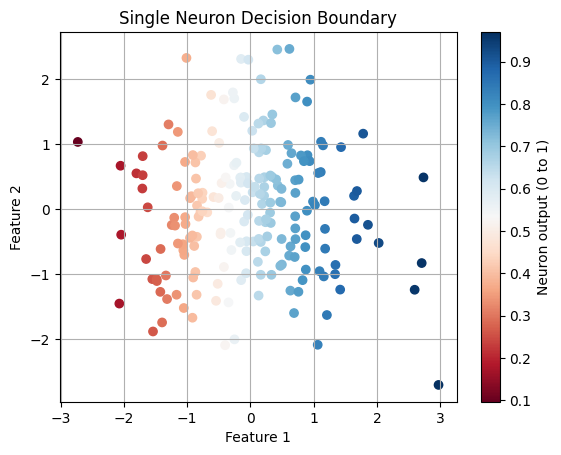

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.randn(200, 2)
w = np.array([1, 0])
b = 0.5

z = np.dot(X, w) + b                  # shape: (200,)
sigmoid_z = 1 / (1 + np.exp(-z))      # shape: (200,)

plt.scatter(X[:, 0], X[:, 1], c=sigmoid_z, cmap='RdBu')
plt.colorbar(label='Neuron output (0 to 1)')
plt.title('Single Neuron Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.show()

### One layer = Many Dot products

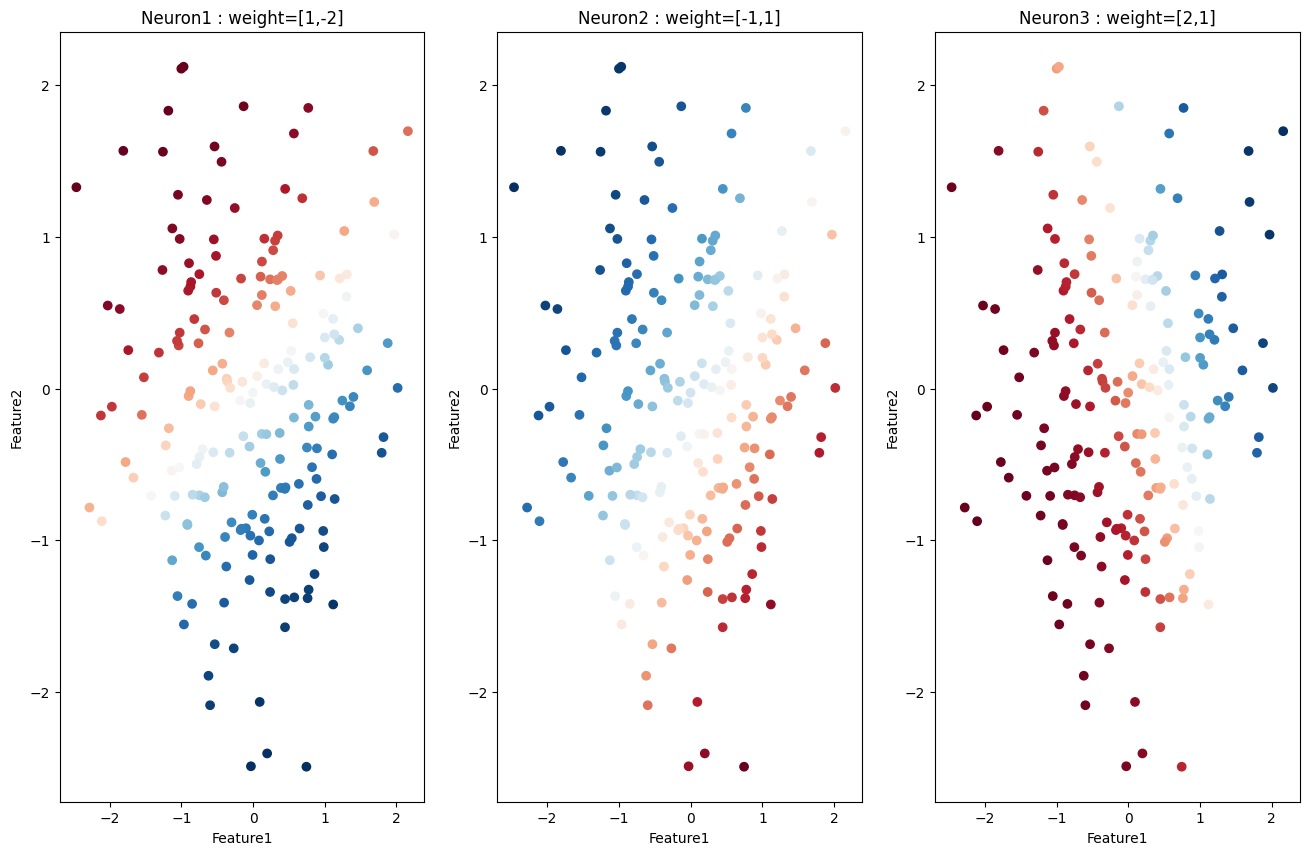

In [4]:
X = np.random.randn(200,2)
W = np.array([[1,-2],[-1,1],[2,1]])
b = np.array([0,0.5,-1])

z = X@W.T +b # shape(200,3)
sigmoid_z = 1/(1+np.exp(-z)) # shape(200,3)
fig,ax = plt.subplots(1,3,figsize=(16,10)) 

ax[0].scatter(X[:,0],X[:,1],c=sigmoid_z[:,0],cmap="RdBu")
ax[1].scatter(X[:,0],X[:,1],c=sigmoid_z[:,1],cmap="RdBu")
ax[2].scatter(X[:,0],X[:,1],c=sigmoid_z[:,2],cmap="RdBu")

ax[0].set_title("Neuron1 : weight=[1,-2]")
ax[1].set_title("Neuron2 : weight=[-1,1]")
ax[2].set_title("Neuron3 : weight=[2,1]")
for a in ax:
    a.set_xlabel("Feature1")
    a.set_ylabel("Feature2")



### Dot Product Vs Cosine Similarity

In [5]:
import numpy as np

# Features: [Sci-Fi, Action]
you = np.array([2.0, 1.0])
user_A = np.array([4.0, 2.0])    # Perfect direction match, small magnitude
user_B = np.array([10.0, 100.0]) # Terrible direction match, huge magnitude

# Raw Dot Product
print("Raw Dot Product:")
print(f"You & User A (Identical Taste): {np.dot(you, user_A)}")       # Output: 10
print(f"You & User B (Action Fanatic): {np.dot(you, user_B)}")       # Output: 120 <-- TRAP!

# Cosine Similarity
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print("\nCosine Similarity:")
print(f"You & User A: {cosine_similarity(you, user_A):.2f}")         # Output: 1.00 <-- Correct!
print(f"You & User B: {cosine_similarity(you, user_B):.2f}")         # Output: 0.53 <-- Correct!

Raw Dot Product:
You & User A (Identical Taste): 10.0
You & User B (Action Fanatic): 120.0

Cosine Similarity:
You & User A: 1.00
You & User B: 0.53


## Exerices PCA (Principal Component Analysis)

Shape of X: (2000, 784)
Min pixel value: 0.0
Max pixel value: 255.0


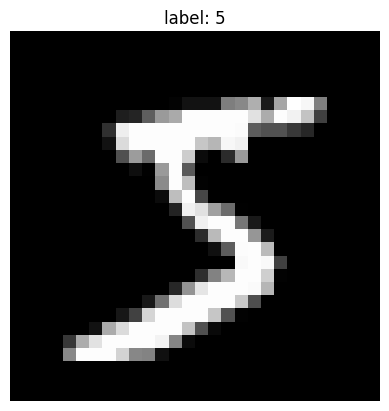

In [6]:
from torchvision.datasets import MNIST

dataset = MNIST(root="./data",download=True)
X = dataset.data.numpy()[:2000].reshape(-1,784).astype(float)
y = dataset.targets.numpy()[:2000]

print(f"Shape of X: {X.shape}")
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")
plt.imshow(X[0].reshape(28,28),cmap="gray")
plt.title(f"label: {y[0]}")
plt.axis("off")
plt.show()

After centering:
Mean of each feature (should be ~0): 2.907257767859051e-16
shape: (2000, 784)


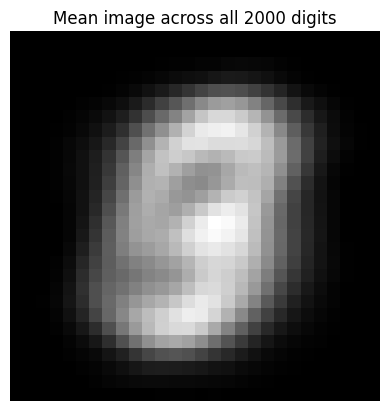

In [7]:
X_normalized = X / 255.0 # Normal pixels from [0,255] => [0,1]
X_centered = X_normalized - X_normalized.mean(axis=0) #shape (2000,784)

print("After centering:")
print("Mean of each feature (should be ~0):",X_centered.mean(axis=0).max())
print("shape:",X_centered.shape)

#visualize the mean image 
plt.imshow(X=X_normalized.mean(axis=0).reshape(28,28),cmap="gray")
plt.title("Mean image across all 2000 digits")
plt.axis("off")
plt.show()


In [8]:
covarience_matrix = (X_centered.T@X_centered)/(2000-1)
print("Covarience matrix Shape: ",covarience_matrix.shape)
print("Is it symmetric? ",np.allclose(covarience_matrix.T,covarience_matrix))


Covarience matrix Shape:  (784, 784)
Is it symmetric?  True


In [9]:
eigenvalues,eigenvectors = np.linalg.eigh(covarience_matrix)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:,::-1]
print("Number of eigenvalues:",len(eigenvalues))
print("largest 5 eigenvalues:",eigenvalues[:5].round(4))
print("smallest 5 eigenvalues:",eigenvalues[-5:].round(4))

Number of eigenvalues: 784
largest 5 eigenvalues: [5.216  3.8877 3.3682 2.874  2.6077]
smallest 5 eigenvalues: [-0. -0. -0. -0. -0.]


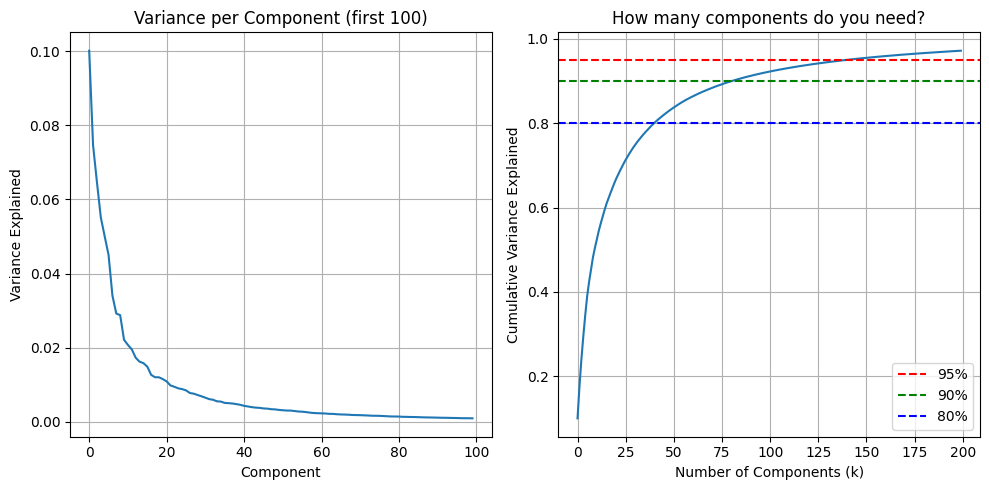

Components needed for 80% variance: 41
Components needed for 90% variance: 82
Components needed for 95% variance: 141


In [10]:
# Calculate cumulative variance explained
total_variance = eigenvalues.sum()
explained_variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(explained_variance_ratio[:100])
plt.xlabel('Component')
plt.ylabel('Variance Explained')
plt.title('Variance per Component (first 100)')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:200])
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.axhline(y=0.80, color='b', linestyle='--', label='80%')
plt.xlabel('Number of Components (k)')
plt.ylabel('Cumulative Variance Explained')
plt.title('How many components do you need?')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Find exact k values
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Components needed for 80% variance: {k_80}")
print(f"Components needed for 90% variance: {k_90}")
print(f"Components needed for 95% variance: {k_95}")

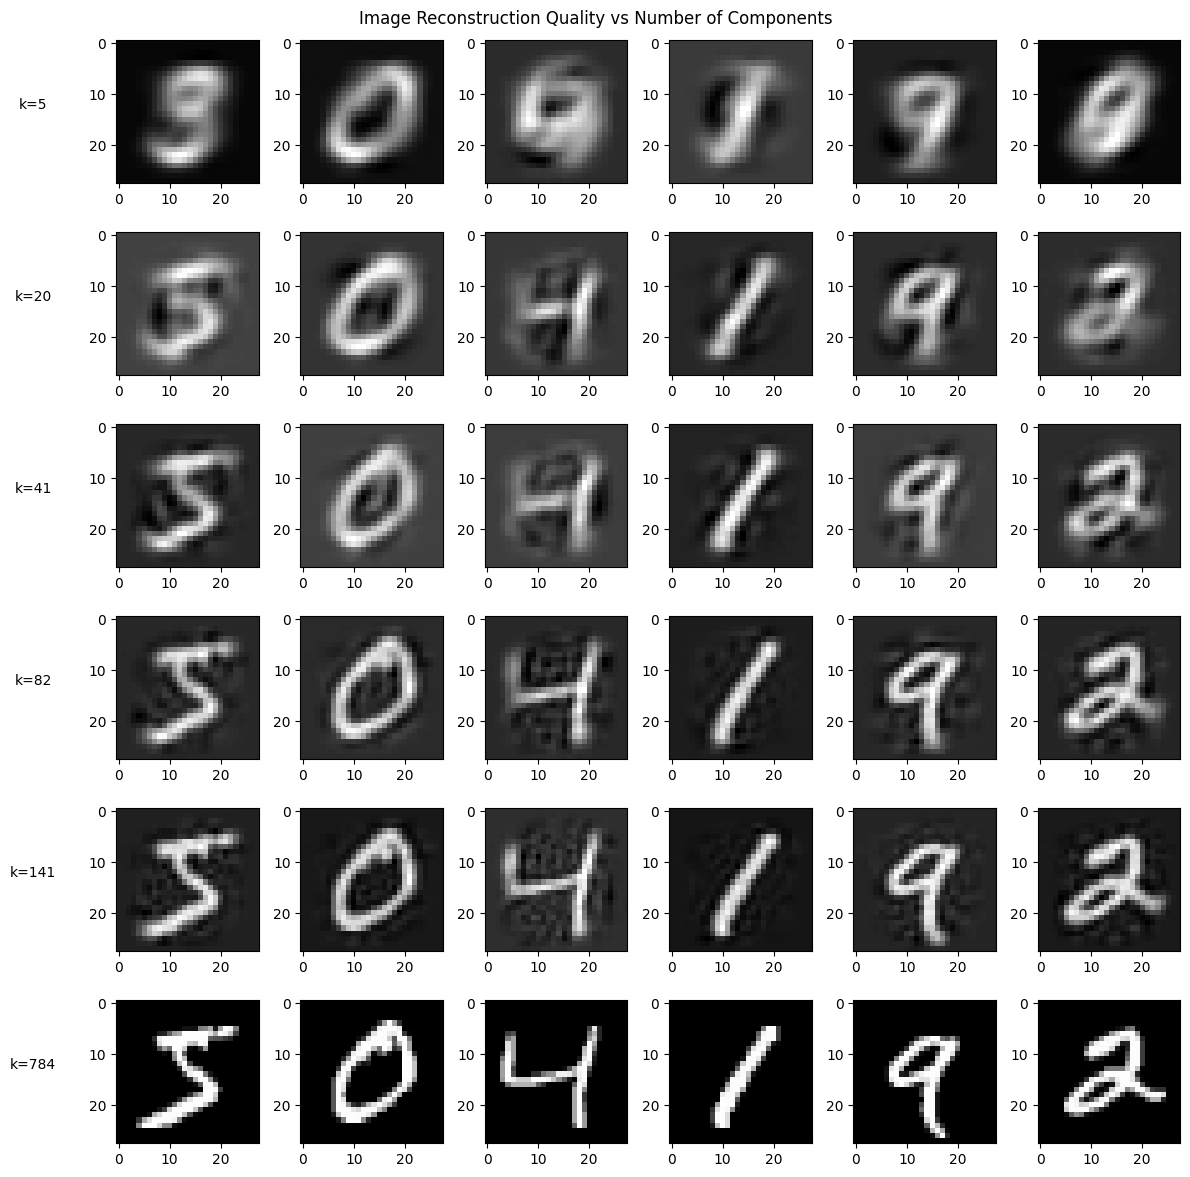

In [11]:
def pca_compress_reconstruct(X_centered, eigenvectors, k):
    # Keep only top-k eigenvectors
    V_k = eigenvectors[:, :k]              # shape: (784, k)
    
    # Project data down to k dimensions
    X_compressed = X_centered @ V_k        # shape: (2000, k)
    
    # Project back up to 784 dimensions
    X_reconstructed = X_compressed @ V_k.T # shape: (2000, 784)
    
    # Add the mean back
    X_reconstructed = X_reconstructed + X_normalized.mean(axis=0)
    return X_reconstructed

# Test multiple values of k
k_values = [5, 20, 41, 82, 141, 784]
fig, axes = plt.subplots(len(k_values), 6, figsize=(12, len(k_values)*2))

for row, k in enumerate(k_values):
    if k == 784:
        X_recon = X_normalized  # original
    else:
        X_recon = pca_compress_reconstruct(X_centered, eigenvectors, k)
    
    for col in range(6):
        axes[row, col].imshow(X_recon[col].reshape(28, 28), cmap='gray')
        if col == 0:
            axes[row, col].set_ylabel(f'k={k}', rotation=0, labelpad=40, fontsize=10)

plt.suptitle('Image Reconstruction Quality vs Number of Components', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
from numpy.random import rand
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

y_int = y.astype(int)

#full data 784 features
X_train_full,X_test_full,y_train,y_test = train_test_split(X_normalized,y_int,test_size=0.3,random_state=42)

#Compressed data (k=41, 80% variance)
X_compressed_41 = X_centered@eigenvectors[:,:41]
X_compressed_141 = X_centered@eigenvectors[:,:141]
X_full = X_centered

split = train_test_split(X_full,X_compressed_41,X_compressed_141,y_int,test_size=0.3,random_state=42)
X_train_full,X_test_full = split[0],split[1]
X_train_41,X_test_41 = split[2],split[3] 
X_train_141,  X_test_141  = split[4], split[5]
y_train,y_test = split[6],split[7]

#Train
clf_full = LogisticRegression(max_iter=1000).fit(X_train_full,y_train)
clf_41 = LogisticRegression(max_iter=1000).fit(X_train_41,y_train)
clf_141 = LogisticRegression(max_iter=1000).fit(X_train_141,y_train)

#results
print(f"Accuracy — Full (784): {clf_full.score(X_test_full,y_test):.3f}")
print(f"Accuracy — Full (141): {clf_141.score(X_test_141,y_test):.3f}")
print(f"Accuracy — Full (41): {clf_41.score(X_test_41,y_test):.3f}")



Accuracy — Full (784): 0.887
Accuracy — Full (141): 0.890
Accuracy — Full (41): 0.867


In [13]:
np.random.seed(0)
n=500
#True Independant Factors
location_score = np.random.randn(n)
size_factor = np.random.randn(n)

# Features (many are derived/correlated)
sqft         = 1000 + 500 * size_factor + np.random.randn(n) * 10
num_rooms    = 3 + 1.5 * size_factor + np.random.randn(n) * 0.1
num_bedrooms = 0.7 * num_rooms + np.random.randn(n) * 0.1    # derived
floor_area   = sqft * 0.092 + np.random.randn(n) * 0.5       # sqft in m²
price        = 200000 + 80000*location_score + 150000*size_factor + np.random.randn(n)*5000
neighborhood = location_score * 10 + np.random.randn(n) * 0.5  # correlated with location

X = np.column_stack([sqft,num_rooms,num_bedrooms,floor_area,price,neighborhood])
feature_names = ['sqft', 'rooms', 'bedrooms', 'floor_area_m2', 'price', 'neighborhood']

In [14]:
X_centered = X-X.mean(axis=0)
C = (X_centered.T@X_centered)/n # (6,6)

eigenvalues,eigenvectors = np.linalg.eigh(C)
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:,::-1]
print(eigenvalues)

[2.68152790e+10 5.74490552e+04 8.09725004e-01 2.14847691e-01
 2.07314567e-02 4.68078423e-03]


In [15]:
print(eigenvectors[:,:])

[[ 2.59774741e-03  9.95124699e-01 -3.62345838e-02 -9.16329160e-02
  -3.01840918e-03  1.19911684e-03]
 [ 7.77442726e-06  2.99067439e-03  1.17868057e-02 -2.35457642e-03
   5.97434855e-01 -8.01821786e-01]
 [ 5.42841627e-06  2.07950815e-03  1.26389812e-02 -1.00368539e-03
   8.01722958e-01  5.97557716e-01]
 [ 2.38888362e-04  9.12950975e-02 -1.10781841e-02  9.95759343e-01
   2.07763857e-03 -1.19836905e-03]
 [ 9.99996597e-01 -2.60591408e-03  1.24162789e-04  4.01511318e-07
  -2.12840047e-06  2.14407937e-07]
 [ 2.75717867e-05 -3.70402379e-02 -9.99132444e-01 -7.75809382e-03
   1.72761521e-02 -1.93024518e-03]]


In [16]:
X_2 = X@eigenvectors[:,:2]
print(X_2.shape)

(500, 2)


In [ ]:
from typing import ReadOnly
from sklearn.datasets import make_blobs,make_circles

X_A,y_A = make_blobs(n_samples=300,centers=2,cluster_std=1.0,random_state=42)
X_B,y_B = make_circles(n_samples=300,noise=0.05,factor=0.4,random_state=42)

X_A_centered = X_A-X_A.mean(axis=0)
X_B_centered = X_B-X_B.mean(axis=0)

C_A = (X_A_centered.T@X_A_centered)/(300-1)
C_B = (X_B_centered.T@X_B_centered)/(300-1)

eigenvalues_A,eigenvectors_A = np.linalg.eigh(C_A)
eigenvalues_B,eigenvectors_B = np.linalg.eigh(C_B)

eigenvalues_A = eigenvalues_A[::-1]
eigenvectors_A = eigenvectors_A[:, ::-1]
eigenvalues_B = eigenvalues_B[::-1]
eigenvectors_B = eigenvectors_B[:, ::-1]

C_A_1 = X_A_centered@eigenvectors_A[:,:1]
C_B_1 = X_B_centered@eigenvectors_B[:,:1]

[26.66676     0.95957127]
[0.2966096  0.28759219]


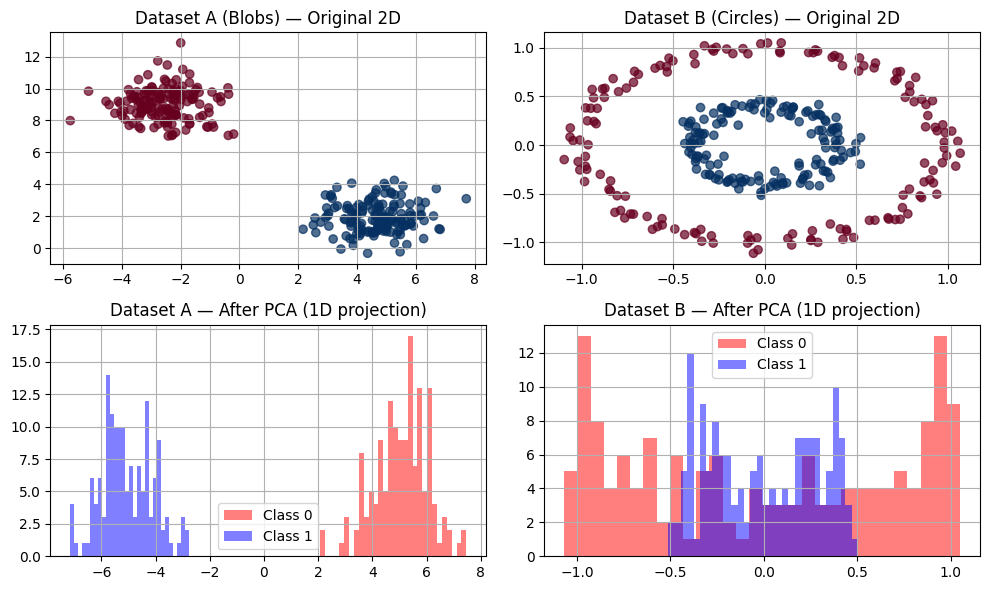

In [41]:
fig,ax = plt.subplots(2,2,figsize=(10,6))

#original 2D Datasets
ax[0,0].scatter(X_A[:,0],X_A[:,1],c=y_A,cmap="RdBu",alpha=0.7)
ax[0, 0].set_title('Dataset A (Blobs) — Original 2D')
ax[0,0].grid()

ax[0,1].scatter(X_B[:,0],X_B[:,1],c=y_B,cmap="RdBu",alpha=0.7)
ax[0,1].set_title('Dataset B (Circles) — Original 2D')
ax[0,1].grid()
#1D projections histogram colored by class
for label, color in [(0, 'red'), (1, 'blue')]:
    ax[1, 0].hist(C_A_1[y_A == label], bins=30, alpha=0.5,
                    color=color, label=f'Class {label}')
    ax[1, 1].hist(C_B_1[y_B == label], bins=30, alpha=0.5,
                    color=color, label=f'Class {label}')

ax[1, 0].set_title('Dataset A — After PCA (1D projection)')
ax[1, 0].legend()
ax[1, 0].grid()
ax[1, 1].set_title('Dataset B — After PCA (1D projection)')
ax[1, 1].legend()
ax[1, 1].grid()
plt.tight_layout()
plt.show()

In [40]:
print("Dataset A eigenvalues: ",eigenvalues_A.round(2))
print("Dataset B eigenvalues: ",eigenvalues_B.round(2))

Dataset A eigenvalues:  [26.67  0.96]
Dataset B eigenvalues:  [0.3  0.29]


**PCA fails on DatasetB because variance is equal in every direction (equal eigenvalues), so PCA finds no meaningful "best direction".**

**TakeAway:**

`PCA` can only find linear Structure.if your data has non-linear geometry (rings,spirals,clusters arranged in curves),`PCA` will not help and can actively destroy the class separation that existed in 2D.

## **SVD (Single Value Decomposition)**

### **1.What are the missing Entries?**

we have a 5x3 matrix with missing values we only know that each row is multiple of the others. 7 known entries and 8 missing

A=[[7,?,?],[?,8,?],[?,12,6],[?,?,2],[21,6,?]]

Q1: we can easily find that the matrix completed is : A=[[7,2,1],[28,8,4],[42,12,6],[14,4,2],[21,6,3]]

Q2: Why rank-1 makes it solvable: So a rank-1 matrix of shape 5×3 lives in a 7-dimensional family, not a 15-dimensional one. That's why 7 well-placed known entries pin it down exactly — each known entry aᵢⱼ = uᵢ · vⱼ gives one equation, and 7 equations for 7 unknowns (generically) has a unique solution.

**Engineering Note:** This parameter counting is exactly why low rank matrix completion works in recommander systems -- a 10000users x 50000 items matrix has 500M entries , but at rank 50 it only has 3M free parameters . **you only need a tiny fraction of ratings to reconstruct the whole thing**

### **Exercise 2 — SVD as a Sum of Rank-1 Ingredients**

We know that every matrix of rank 1 is just u*v^T which is a column vector time a row vector

**we need to prove that the SVD of mxn matrix A can be written like this**

A = USV^T <===> ∑ `(i=1 ===> min(m,n))` σi x ui x vi^T

**Think about what S does. S is diagonal, so when you compute USV⊤, the diagonal entry sᵢ acts as a "matchmaker" — it pairs the i-th column of U with the i-th row of V⊤ and scales their contribution:**

**Then U · (SV⊤): each column uᵢ of U gets multiplied by the corresponding row σᵢvᵢ⊤, giving:**

A = u1*(σ1*v1^T) + u2*(σ2*v2^T) + ..........

**That's the whole proof. The diagonal structure of S is what makes each singular value "route" exactly one column of U to one row of V⊤. If S were a full matrix, you wouldn't get this clean decomposition.**

### **Exercise 4 — Building the Truncated SVD (Low-Rank Approximation)**